In [1]:
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import warnings
from tensorflow_addons.losses import SigmoidFocalCrossEntropy
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)

# Training configuration
BATCH_SIZE = 8
IMAGE_SIZE = 224
NUM_CLASSES = 14
EPOCHS = 100
LEARNING_RATE = 1e-4
np.random.seed(RANDOM_SEED)

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision training enabled")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.venv\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.venv\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
So

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9
Mixed precision training enabled
TensorFlow version: 2.10.0
GPU Available: True


In [2]:
BASE_DIR = "./dataset_unbalanced/"
CSV_PATH = os.path.join(BASE_DIR, "Data_Entry_2017.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

# Disease labels for multi-label classification
DISEASE_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

print(f"Number of disease classes: {len(DISEASE_LABELS)}")
print(f"Disease labels: {DISEASE_LABELS}")

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df.rename(columns={'Image Index': 'Path'})

# Create binary columns for each disease label
for disease in DISEASE_LABELS:
    df[disease] = df['Finding Labels'].apply(lambda x: int(disease in x.split('|')))

df = df[['Path'] + DISEASE_LABELS]

print(f"Total samples: {len(df)}")
print(f"Dataset shape: {df.shape}")

Number of disease classes: 14
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total samples: 112120
Dataset shape: (112120, 15)


Class Distribution in Balanced Dataset:
Atelectasis         : 11559 samples (10.31%)
Cardiomegaly        :  2776 samples ( 2.48%)
Consolidation       :  4667 samples ( 4.16%)
Edema               :  2303 samples ( 2.05%)
Effusion            : 13317 samples (11.88%)
Emphysema           :  2516 samples ( 2.24%)
Fibrosis            :  1686 samples ( 1.50%)
Hernia              :   227 samples ( 0.20%)
Infiltration        : 19894 samples (17.74%)
Mass                :  5782 samples ( 5.16%)
Nodule              :  6331 samples ( 5.65%)
Pleural_Thickening  :  3385 samples ( 3.02%)
Pneumonia           :  1431 samples ( 1.28%)
Pneumothorax        :  5302 samples ( 4.73%)


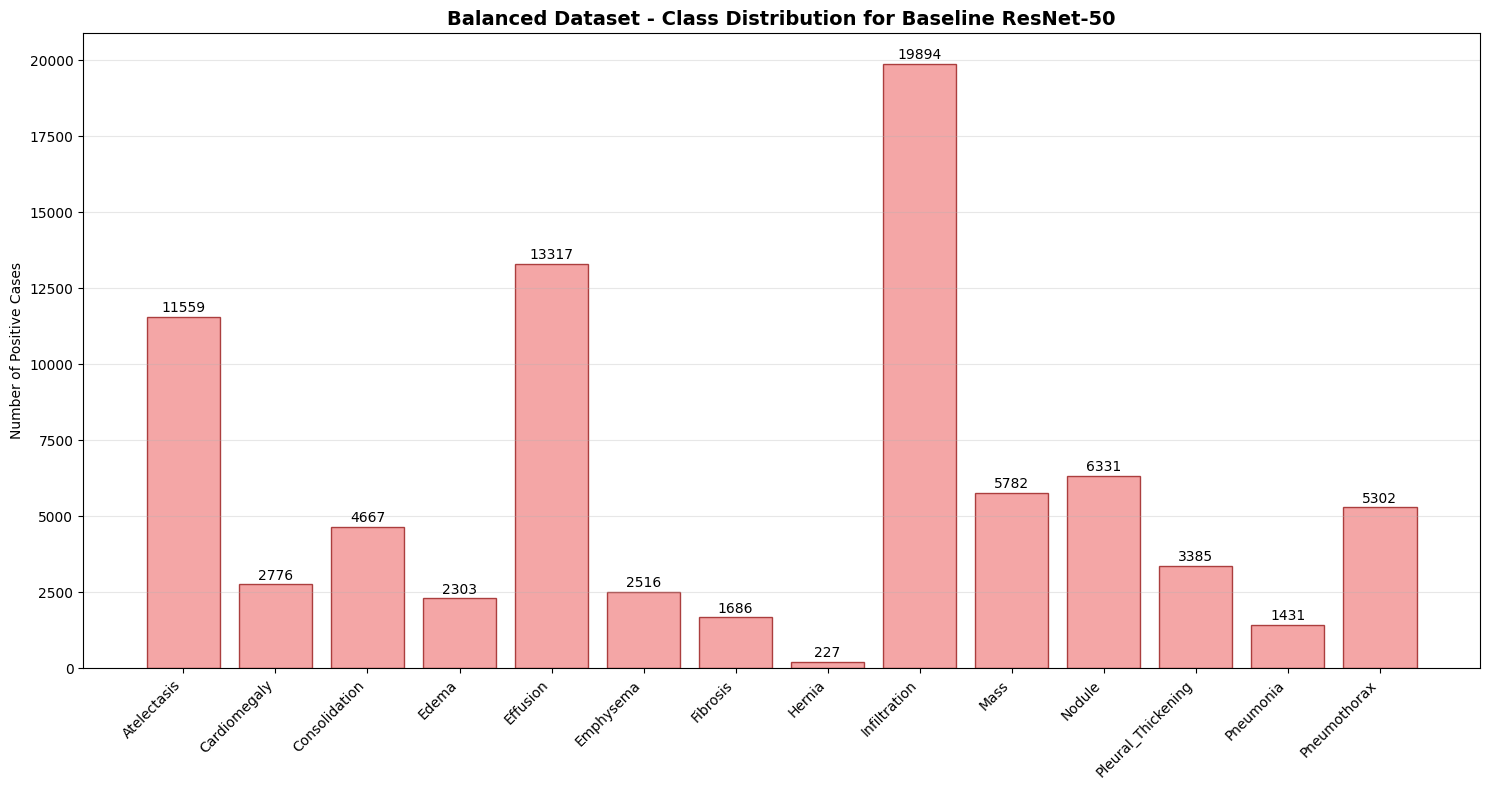


Dataset Balance Analysis:
Minimum class count: 227
Maximum class count: 19894
Balance ratio: 0.011
Coefficient of variation: 0.951


In [3]:
# Analyze class distribution
class_counts = df[DISEASE_LABELS].sum()
class_percentages = (class_counts / len(df)) * 100

print("Class Distribution in Balanced Dataset:")
print("=" * 50)
for label, count, percentage in zip(DISEASE_LABELS, class_counts, class_percentages):
    print(f"{label:20s}: {count:5d} samples ({percentage:5.2f}%)")

# Visualize class distribution
plt.figure(figsize=(15, 8))
bars = plt.bar(range(len(DISEASE_LABELS)), class_counts, 
               color='lightcoral', alpha=0.7, edgecolor='darkred', linewidth=1)
plt.xticks(range(len(DISEASE_LABELS)), DISEASE_LABELS, rotation=45, ha='right')
plt.ylabel('Number of Positive Cases')
plt.title('Balanced Dataset - Class Distribution for Baseline ResNet-50', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars, class_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Calculate dataset balance metrics
min_class_count = class_counts.min()
max_class_count = class_counts.max()
balance_ratio = min_class_count / max_class_count

print(f"\nDataset Balance Analysis:")
print(f"Minimum class count: {min_class_count}")
print(f"Maximum class count: {max_class_count}")
print(f"Balance ratio: {balance_ratio:.3f}")
print(f"Coefficient of variation: {(class_counts.std() / class_counts.mean()):.3f}")

In [4]:
# Create stratified split based on disease presence
df['disease_count'] = df[DISEASE_LABELS].sum(axis=1)
df['has_any_disease'] = (df['disease_count'] > 0).astype(int)

# Stratified split to maintain disease distribution
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=df['has_any_disease']
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Train/Val ratio: {len(train_df)/len(val_df):.2f}")

# Verify stratification worked
train_positive_rate = train_df['has_any_disease'].mean()
val_positive_rate = val_df['has_any_disease'].mean()
print(f"Training positive rate: {train_positive_rate:.3f}")
print(f"Validation positive rate: {val_positive_rate:.3f}")
print(f"Stratification difference: {abs(train_positive_rate - val_positive_rate):.4f}")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


Training samples: 89696
Validation samples: 22424
Train/Val ratio: 4.00
Training positive rate: 0.462
Validation positive rate: 0.462
Stratification difference: 0.0000


In [5]:
def load_and_preprocess_image(image_path, labels, is_training=True):
    """Load and preprocess image with optional augmentation"""
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.cast(image, tf.float32)
    
    # Resize to target size
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Normalize to [0, 1]
    image = image / 255.0
    
    if is_training:
        # Data augmentation for training (medical image appropriate)
        # Small rotations
        image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        
        # Random brightness adjustment
        image = tf.image.random_brightness(image, max_delta=0.1)
        
        # Random contrast adjustment
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        
        # Small random crops with padding
        image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE + 20, IMAGE_SIZE + 20)
        image = tf.image.random_crop(image, [IMAGE_SIZE, IMAGE_SIZE, 3])
    
    # Ensure final normalization
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, labels

def create_tf_dataset(dataframe, image_dir, batch_size, is_training=True):
    """Create optimized tf.data.Dataset with prefetching"""
    
    # Prepare file paths and labels
    image_paths = [os.path.join(image_dir, path) for path in dataframe['Path'].values]
    labels = dataframe[DISEASE_LABELS].values.astype(np.float32)
    
    # Create dataset from paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if is_training:
        # Shuffle for training
        dataset = dataset.shuffle(buffer_size=1000, seed=RANDOM_SEED)
    
    # Map preprocessing function
    dataset = dataset.map(
        lambda path, label: load_and_preprocess_image(path, label, is_training),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch for performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    if is_training:
        # Repeat for multiple epochs
        dataset = dataset.repeat()
    
    return dataset

# Create optimized datasets
print("Creating optimized tf.data pipelines...")

train_dataset = create_tf_dataset(
    train_df, 
    IMAGE_DIR, 
    BATCH_SIZE, 
    is_training=True
)

val_dataset = create_tf_dataset(
    val_df, 
    IMAGE_DIR, 
    BATCH_SIZE, 
    is_training=False
)

# Calculate steps per epoch
steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(val_df) // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print("Optimized data pipeline created with tf.data.AUTOTUNE prefetching")

Creating optimized tf.data pipelines...
Steps per epoch: 11212
Validation steps: 2803
Optimized data pipeline created with tf.data.AUTOTUNE prefetching


In [ ]:
def create_baseline_resnet50(input_shape=(224, 224, 3), num_classes=14):
    """
    Create baseline ResNet-50 model for comparative analysis
    
    Architecture:
    - Standard ResNet-50 backbone (ImageNet pretrained)
    - Global Average Pooling
    - Dense classification head
    - No attention mechanisms (pure baseline)
    """
    
    # Input layer
    inputs = tf.keras.Input(shape=input_shape, name='input_images')
    
    # ResNet-50 backbone (pretrained on ImageNet)
    backbone = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs,
        pooling=None  # We'll add our own pooling
    )
    
    # Freeze early layers, train only top layers for transfer learning
    trainable_layers = 30  # Train top 30 layers
    for i, layer in enumerate(backbone.layers):
        if i < len(backbone.layers) - trainable_layers:
            layer.trainable = False
        else:
            layer.trainable = True
    
    # Get features from ResNet backbone
    x = backbone.output  # Shape: (batch_size, 7, 7, 2048)
    
    # Global Average Pooling to reduce spatial dimensions
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # Classification head with regularization
    x = tf.keras.layers.Dense(512, activation='relu', name='dense_512')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_512')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout_512')(x)
    
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_256')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout_256')(x)
    
    # Final output layer (float32 for mixed precision compatibility)
    outputs = tf.keras.layers.Dense(
        num_classes, 
        activation='sigmoid', 
        dtype='float32',  # Ensure float32 output for mixed precision
        name='predictions'
    )(x)
    
    # Create model
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='Baseline_ResNet50')
    
    return model, backbone

# Create baseline model
print("Creating Baseline ResNet-50 model...")
model, backbone = create_baseline_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=NUM_CLASSES
)

print(f"Model created successfully!")
print(f"Total parameters: {model.count_params():,}")

# Count trainable parameters
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {model.count_params() - trainable_params:,}")

# Display model architecture
model.summary(line_length=100)

# %% [markdown]
# ## 7. Model Compilation and Training Setup

# %%
# Compile model with binary crossentropy (baseline loss)
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7
    ),
    loss=SigmoidFocalCrossEntropy(
        alpha=0.25,     # Standard 25% for positive class
        gamma=3.0,      # Higher gamma for very hard examples
        reduction='sum_over_batch_size'
    ),
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Model compiled with binary crossentropy loss")

# Create output directory
os.makedirs('./output', exist_ok=True)

# Define callbacks for training
callbacks = [
    # Save best model based on validation AUC
    tf.keras.callbacks.ModelCheckpoint(
        filepath='./output/sigmoid_resnet50_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
        save_freq='epoch'
    ),
    
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # CSV logger for training history
    tf.keras.callbacks.CSVLogger(
        './output/baseline_resnet50_training.csv',
        separator=',',
        append=False
    )
]

print("Training callbacks configured")

Creating Baseline ResNet-50 model...


In [ ]:
print("Starting Baseline ResNet-50 Training...")
print("=" * 60)
print(f"Training configuration:")
print(f"  - Model: ResNet-50 (baseline)")
print(f"  - Loss function: Sigmoid Crossentropy")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Mixed precision: Enabled")
print("=" * 60)

# Train the model
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

# Save final model
model.save('./output/sigmoid_resnet50_final.keras')
print("Final model saved")

In [ ]:
# Continue training to 100 epochs
print("Continuing training...")

model = tf.keras.models.load_model('./output/baseline_resnet50_best.keras')

# Continue training with existing callbacks
history_continued = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    initial_epoch=25,  # Continue from epoch 26 (last best was epoch 25)
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,  # Use your existing callbacks
    verbose=1
)

print("Training completed! Final model saved by ModelCheckpoint callback.")

In [ ]:
def plot_training_history(history_continued):
    """Plot training history with subplots"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Baseline ResNet-50 Training History', fontsize=16, fontweight='bold')
    
    # Plot loss
    axes[0, 0].plot(history_continued.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(history_continued.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Binary Crossentropy Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot AUC
    axes[0, 1].plot(history_continued.history['auc'], 'b-', label='Training AUC', linewidth=2)
    axes[0, 1].plot(history_continued.history['val_auc'], 'r-', label='Validation AUC', linewidth=2)
    axes[0, 1].set_title('Area Under Curve (AUC)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1, 0].plot(history_continued.history['binary_accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1, 0].plot(history_continued.history['val_binary_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1, 0].set_title('Binary Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot precision and recall
    axes[1, 1].plot(history_continued.history['precision'], 'g-', label='Training Precision', linewidth=2)
    axes[1, 1].plot(history_continued.history['val_precision'], 'orange', label='Val Precision', linewidth=2)
    axes[1, 1].plot(history_continued.history['recall'], 'purple', label='Training Recall', linewidth=2)
    axes[1, 1].plot(history_continued.history['val_recall'], 'brown', label='Val Recall', linewidth=2)
    axes[1, 1].set_title('Precision and Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_resnet50_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot training history
plot_training_history(history_continued)

# Print final training metrics
final_epoch = len(history_continued.history['loss']) - 1
print(f"\nFinal Training Metrics (Epoch {final_epoch + 1}):")
print("=" * 50)
print(f"Training Loss:        {history_continued.history['loss'][-1]:.4f}")
print(f"Validation Loss:      {history_continued.history['val_loss'][-1]:.4f}")
print(f"Training AUC:         {history_continued.history['auc'][-1]:.4f}")
print(f"Validation AUC:       {history_continued.history['val_auc'][-1]:.4f}")
print(f"Training Accuracy:    {history_continued.history['binary_accuracy'][-1]:.4f}")
print(f"Validation Accuracy:  {history_continued.history['val_binary_accuracy'][-1]:.4f}")

# Check for overfitting
train_val_loss_diff = history_continued.history['loss'][-1] - history_continued.history['val_loss'][-1]
train_val_auc_diff = history_continued.history['auc'][-1] - history_continued.history['val_auc'][-1]

print(f"\nGeneralization Analysis:")
print(f"Train-Val Loss Difference: {train_val_loss_diff:.4f}")
print(f"Train-Val AUC Difference:  {train_val_auc_diff:.4f}")

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve
import matplotlib.pyplot as plt

def optimize_thresholds_per_class(model, val_dataset, val_df, disease_labels, method='f1'):
    """
    Find optimal threshold for each disease class
    
    Args:
        model: trained model
        val_dataset: validation tf.data.Dataset 
        val_df: validation dataframe with true labels
        disease_labels: list of disease names
        method: 'f1', 'youden', or 'precision_recall_balance'
    
    Returns:
        optimal_thresholds: dict with optimal threshold for each disease
        results: detailed results for analysis
    """
    
    print("Getting model predictions on validation set...")
    
    # Get predictions from model
    val_predictions = model.predict(val_dataset, verbose=1)
    
    # Get true labels
    y_true = val_df[disease_labels].values
    
    print(f"Predictions shape: {val_predictions.shape}")
    print(f"True labels shape: {y_true.shape}")
    
    optimal_thresholds = {}
    results = {}
    
    print("\nOptimizing thresholds for each disease class...")
    print("=" * 60)
    
    for i, disease in enumerate(disease_labels):
        print(f"Optimizing {disease}...")
        
        # Get predictions and true labels for this disease
        y_pred_proba = val_predictions[:, i]
        y_true_class = y_true[:, i]
        
        # Test different thresholds
        thresholds_to_test = np.arange(0.1, 0.9, 0.05)
        best_threshold = 0.5
        best_score = 0.0
        
        threshold_results = []
        
        for threshold in thresholds_to_test:
            y_pred_binary = (y_pred_proba >= threshold).astype(int)
            
            # Skip if all predictions are 0 or 1
            if len(np.unique(y_pred_binary)) == 1:
                continue
                
            # Calculate metrics
            f1 = f1_score(y_true_class, y_pred_binary)
            precision = precision_score(y_true_class, y_pred_binary, zero_division=0)
            recall = recall_score(y_true_class, y_pred_binary, zero_division=0)
            
            threshold_results.append({
                'threshold': threshold,
                'f1': f1,
                'precision': precision,
                'recall': recall
            })
            
            # Choose best threshold based on method
            if method == 'f1':
                score = f1
            elif method == 'youden':
                # Youden's J statistic (sensitivity + specificity - 1)
                tn = np.sum((y_true_class == 0) & (y_pred_binary == 0))
                fp = np.sum((y_true_class == 0) & (y_pred_binary == 1))
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                score = recall + specificity - 1
            elif method == 'precision_recall_balance':
                # Balanced F1 where precision and recall are equally important
                score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            if score > best_score:
                best_score = score
                best_threshold = threshold
        
        optimal_thresholds[disease] = best_threshold
        results[disease] = {
            'best_threshold': best_threshold,
            'best_score': best_score,
            'threshold_results': threshold_results,
            'class_distribution': {
                'positive_samples': int(y_true_class.sum()),
                'negative_samples': int(len(y_true_class) - y_true_class.sum()),
                'positive_rate': float(y_true_class.mean())
            }
        }
        
        # Print results for this disease
        print(f"  Best threshold: {best_threshold:.3f} (score: {best_score:.3f})")
        
    return optimal_thresholds, results

def evaluate_with_optimized_thresholds(model, val_dataset, val_df, disease_labels, optimal_thresholds):
    """
    Evaluate model performance using optimized thresholds
    """
    print("Evaluating with optimized thresholds...")
    
    # Get predictions
    val_predictions = model.predict(val_dataset, verbose=1)
    y_true = val_df[disease_labels].values
    
    # Apply optimized thresholds
    y_pred_optimized = np.zeros_like(val_predictions)
    for i, disease in enumerate(disease_labels):
        threshold = optimal_thresholds[disease]
        y_pred_optimized[:, i] = (val_predictions[:, i] >= threshold).astype(int)
    
    # Calculate metrics for each class
    print("\nPer-class performance with optimized thresholds:")
    print("=" * 80)
    print(f"{'Disease':<20} {'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
    print("=" * 80)
    
    overall_metrics = {'precision': [], 'recall': [], 'f1': []}
    
    for i, disease in enumerate(disease_labels):
        precision = precision_score(y_true[:, i], y_pred_optimized[:, i], zero_division=0)
        recall = recall_score(y_true[:, i], y_pred_optimized[:, i], zero_division=0)
        f1 = f1_score(y_true[:, i], y_pred_optimized[:, i], zero_division=0)
        
        overall_metrics['precision'].append(precision)
        overall_metrics['recall'].append(recall)
        overall_metrics['f1'].append(f1)
        
        print(f"{disease:<20} {optimal_thresholds[disease]:<10.3f} {precision:<10.3f} {recall:<10.3f} {f1:<10.3f}")
    
    # Calculate macro averages
    macro_precision = np.mean(overall_metrics['precision'])
    macro_recall = np.mean(overall_metrics['recall'])
    macro_f1 = np.mean(overall_metrics['f1'])
    
    print("=" * 80)
    print(f"{'MACRO AVERAGE':<20} {'-':<10} {macro_precision:<10.3f} {macro_recall:<10.3f} {macro_f1:<10.3f}")
    
    return overall_metrics

def plot_threshold_analysis(results, disease_labels):
    """
    Plot threshold analysis for top diseases
    """
    # Select diseases with most samples for plotting
    diseases_by_samples = sorted(
        [(disease, results[disease]['class_distribution']['positive_samples']) 
         for disease in disease_labels],
        key=lambda x: x[1], reverse=True
    )
    
    top_diseases = [d[0] for d in diseases_by_samples[:4]]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Threshold Optimization Analysis (Top 4 Diseases by Sample Count)', fontsize=14)
    axes = axes.ravel()
    
    for idx, disease in enumerate(top_diseases):
        threshold_data = results[disease]['threshold_results']
        
        thresholds = [r['threshold'] for r in threshold_data]
        f1_scores = [r['f1'] for r in threshold_data]
        precision_scores = [r['precision'] for r in threshold_data]
        recall_scores = [r['recall'] for r in threshold_data]
        
        axes[idx].plot(thresholds, f1_scores, 'b-', label='F1 Score', linewidth=2)
        axes[idx].plot(thresholds, precision_scores, 'r--', label='Precision', alpha=0.7)
        axes[idx].plot(thresholds, recall_scores, 'g--', label='Recall', alpha=0.7)
        
        # Mark optimal threshold
        best_threshold = results[disease]['best_threshold']
        best_f1 = max(f1_scores) if f1_scores else 0
        axes[idx].axvline(x=best_threshold, color='orange', linestyle=':', 
                         label=f'Optimal ({best_threshold:.2f})')
        
        axes[idx].set_title(f'{disease}\n(+{results[disease]["class_distribution"]["positive_samples"]} samples)')
        axes[idx].set_xlabel('Threshold')
        axes[idx].set_ylabel('Score')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig('./output/threshold_optimization_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Usage example:
print("Starting threshold optimization...")

# Optimize thresholds
optimal_thresholds, detailed_results = optimize_thresholds_per_class(
    model=model,
    val_dataset=val_dataset,
    val_df=val_df,
    disease_labels=DISEASE_LABELS,
    method='f1'  # or 'youden' or 'precision_recall_balance'
)

# Evaluate with optimized thresholds
performance_metrics = evaluate_with_optimized_thresholds(
    model=model,
    val_dataset=val_dataset, 
    val_df=val_df,
    disease_labels=DISEASE_LABELS,
    optimal_thresholds=optimal_thresholds
)

# Plot analysis
plot_threshold_analysis(detailed_results, DISEASE_LABELS)

# Save optimal thresholds for future use
import json
with open('./output/optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)

print("Threshold optimization complete!")
print(f"Optimal thresholds saved to './output/optimal_thresholds.json'")

In [ ]:
# Get predictions and true labels from the baseline model
def get_baseline_predictions(model, dataset, steps):
    """Get predictions and true labels from the baseline model"""
    print("Generating predictions from baseline model...")
    
    # Get predictions
    y_pred = model.predict(dataset, steps=steps, verbose=1)
    
    # Get true labels by iterating through dataset
    y_true = []
    count = 0
    for batch_x, batch_y in dataset:
        y_true.append(batch_y.numpy())
        count += 1
        if count >= steps:
            break
    
    y_true = np.vstack(y_true)
    
    print(f"Predictions shape: {y_pred.shape}")
    print(f"True labels shape: {y_true.shape}")
    
    return y_true, y_pred

# Plot ROC curves for baseline model
def plot_baseline_roc_curves(y_true, y_pred, disease_labels):
    """Plot ROC curves for each disease class - baseline model"""
    
    n_classes = len(disease_labels)
    
    # Calculate ROC curve for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot all ROC curves
    plt.figure(figsize=(15, 12))
    
    # Create subplot grid
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    fig.suptitle('Baseline ResNet-50 ROC Curves (Binary Cross-Entropy on Balanced Dataset)', 
                 fontsize=16, fontweight='bold')
    
    # Colors for different classes
    colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
    
    # Plot individual ROC curves
    for i in range(n_classes):
        row = i // 4
        col = i % 4
        
        axes[row, col].plot(fpr[i], tpr[i], color=colors[i], lw=2,
                           label=f'AUC = {roc_auc[i]:.3f}')
        axes[row, col].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        axes[row, col].set_xlim([0.0, 1.0])
        axes[row, col].set_ylim([0.0, 1.05])
        axes[row, col].set_xlabel('False Positive Rate')
        axes[row, col].set_ylabel('True Positive Rate')
        axes[row, col].set_title(f'{disease_labels[i]}')
        axes[row, col].legend(loc="lower right")
        axes[row, col].grid(True, alpha=0.3)
    
    # Remove empty subplots
    for i in range(n_classes, 16):
        row = i // 4
        col = i % 4
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
    
    return roc_auc

# Plot all baseline ROC curves on single plot
def plot_baseline_combined_roc(y_true, y_pred, disease_labels):
    """Plot all baseline ROC curves on single plot"""
    
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(disease_labels)))
    
    roc_aucs = []
    
    for i, (label, color) in enumerate(zip(disease_labels, colors)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        roc_aucs.append(roc_auc)
        
        plt.plot(fpr, tpr, color=color, lw=2, alpha=0.8,
                label=f'{label} (AUC = {roc_auc:.3f})')
    
    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Baseline ResNet-50 ROC Curves - All Disease Classes\n(Binary Cross-Entropy on Balanced Dataset)', 
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Add mean AUC
    mean_auc = np.mean(roc_aucs)
    plt.text(0.6, 0.2, f'Mean AUC: {mean_auc:.3f}', fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return roc_aucs

# Print baseline AUC summary
def print_baseline_auc_summary(roc_aucs, disease_labels):
    """Print baseline AUC scores for each disease"""
    print("\nBaseline ResNet-50 ROC-AUC Scores by Disease:")
    print("(Binary Cross-Entropy on Balanced Dataset)")
    print("=" * 50)
    for label, auc_score in zip(disease_labels, roc_aucs):
        print(f"{label:<20}: {auc_score:.3f}")
    print("=" * 50)
    print(f"{'Mean AUC':<20}: {np.mean(roc_aucs):.3f}")
    print("=" * 50)

# Set up baseline dataset paths (balanced dataset)
BASELINE_BASE_DIR = "./dataset_balanced/"
BASELINE_CSV_PATH = os.path.join(BASELINE_BASE_DIR, "new_labels.csv")
BASELINE_IMAGE_DIR = os.path.join(BASELINE_BASE_DIR, "new_images/new_images")

print("Loading baseline dataset...")
baseline_df = pd.read_csv(BASELINE_CSV_PATH)
baseline_df = baseline_df[['Path'] + DISEASE_LABELS]

print(f"Baseline dataset samples: {len(baseline_df)}")

# Create baseline validation dataset (same split logic as original)
baseline_df['disease_count'] = baseline_df[DISEASE_LABELS].sum(axis=1)
baseline_df['has_any_disease'] = (baseline_df['disease_count'] > 0).astype(int)

baseline_train_df, baseline_val_df = train_test_split(
    baseline_df, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=baseline_df['has_any_disease']
)

baseline_val_df = baseline_val_df.reset_index(drop=True)
print(f"Baseline validation samples: {len(baseline_val_df)}")

# Create baseline validation dataset
baseline_val_dataset = create_tf_dataset(
    baseline_val_df, 
    BASELINE_IMAGE_DIR, 
    BATCH_SIZE, 
    is_training=False
)

baseline_validation_steps = len(baseline_val_df) // BATCH_SIZE
print(f"Baseline validation steps: {baseline_validation_steps}")

# Load baseline model and generate ROC analysis
print("\nLoading baseline ResNet-50 model...")
baseline_model = tf.keras.models.load_model('./output/baseline_resnet50_best.keras')

print("Model loaded successfully!")
print(f"Model architecture: {baseline_model.name}")
print(f"Input shape: {baseline_model.input_shape}")
print(f"Output shape: {baseline_model.output_shape}")

# Get predictions on baseline validation set
print("\nGenerating predictions on baseline validation set...")
y_true_baseline, y_pred_baseline = get_baseline_predictions(baseline_model, baseline_val_dataset, baseline_validation_steps)

# Generate individual ROC curves (4x4 grid)
print("\nGenerating individual ROC curves...")
baseline_roc_aucs = plot_baseline_roc_curves(y_true_baseline, y_pred_baseline, DISEASE_LABELS)

# Generate combined ROC curve (all diseases on one plot)
print("\nGenerating combined ROC curve...")
baseline_combined_aucs = plot_baseline_combined_roc(y_true_baseline, y_pred_baseline, DISEASE_LABELS)

# Print AUC summary
print_baseline_auc_summary(baseline_combined_aucs, DISEASE_LABELS)